# Dự đoán tiểu đường (Pima Indians) — notebook khớp `main.tex`

Notebook này triển khai **đúng giao thức** mô tả trong báo cáo LaTeX (`main.tex`):

- **Dữ liệu:** Pima Indians Diabetes (UCI), không dùng SMOTE/làm giàu **trước** khi chia tập.
- **Mất cân bằng lớp:** chỉ **stratify** khi `train_test_split` và khi CV; `class_weight=None` (có thể đổi thành `'balanced'` trong lưới nếu muốn — ghi rõ trong Phụ lục).
- **Chống leakage:** `SimpleImputer` + `StandardScaler` nằm trong `Pipeline`, chỉ `fit` trên **train** hoặc **train fold** (qua `GridSearchCV`).
- **Selection vs evaluation:** `GridSearchCV` (vòng trong, 5-fold stratified) chỉ trên tập train; đánh giá trên **test hold-out 20%** (lặp với nhiều `random_state` split để có mean±std).
- **Mô hình:** Logistic Regression, SVM (RBF), Random Forest, KNN + baseline **Majority** (`DummyClassifier`).
- **Chỉ số:** Accuracy, Precision, Recall, F1, ROC–AUC; tùy chọn kiểm định cặp (Wilcoxon) và khoảng tin cậy 95% trên các lần split.
- **RQ2:** hệ số LR (đã chuẩn hóa), `feature_importances_` của RF; SHAP nếu cài extra `shap` (`uv sync --extra shap`).
- **Đặc trưng:** dùng đủ 8 biến gốc của Pima; không PCA / không loại biến theo tương quan (khớp mục Lựa chọn đặc trưng trong `main.tex` khi ghi ``giữ toàn bộ đặc trưng'').

## Môi trường (`uv`)

Từ thư mục gốc repo (`ppnckh/`):

```bash
uv sync
uv run jupyter lab resources/diabetes.ipynb
```

Hoặc chỉ chạy toàn bộ notebook:

```bash
uv run jupyter execute resources/diabetes.ipynb
```

In [15]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=UserWarning)

# --- Tái lập (khớp Phụ lục D / main.tex) ---
RANDOM_STATE_CV = 42       # StratifiedKFold + GridSearchCV
SEED_MODEL = 42            # LR, SVM, RF
SPLIT_SEEDS = [0, 1, 2, 3, 4]  # Độ ổn định qua nhiều lần chia train/test (cùng tỷ lệ 80/20)
TEST_SIZE = 0.2
N_INNER_SPLITS = 5

print("Python", sys.version.split()[0])
print("NumPy", np.__version__)
print("pandas", pd.__version__)
import sklearn

print("scikit-learn", sklearn.__version__)

# Jupyter: không có __file__ — tìm thư mục gốc repo (có main.tex)
def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "main.tex").is_file():
        return cwd
    if (cwd.parent / "main.tex").is_file():
        return cwd.parent
    return cwd


REPO_ROOT = _repo_root()
DATA_DIR = REPO_ROOT / "resources" / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "pima-indians-diabetes.data.csv"
# UCI / Jason Brownlee mirror (8 đặc trưng + nhãn, không header)
DATA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

COLS = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome",
]

# Pima: giá trị 0 thường là thiếu cho các biến sinh hóa (trừ Pregnancies & Outcome)
ZERO_TO_NA = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

Python 3.13.12
NumPy 2.4.3
pandas 3.0.1
scikit-learn 1.8.0


In [16]:
def load_pima(path: Path = DATA_PATH, url: str = DATA_URL) -> pd.DataFrame:
    if not path.exists():
        import urllib.request

        print("Đang tải", url, "->", path)
        urllib.request.urlretrieve(url, path)
    df = pd.read_csv(path, header=None, names=COLS)
    for c in ZERO_TO_NA:
        df.loc[df[c] == 0, c] = np.nan
    return df


diabetes = load_pima()
X = diabetes.drop(columns=["Outcome"])
y = diabetes["Outcome"].astype(int)

print("Shape", X.shape, "Positive rate", f"{y.mean():.3f}")
diabetes.head()

Shape (768, 8) Positive rate 0.349


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [17]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


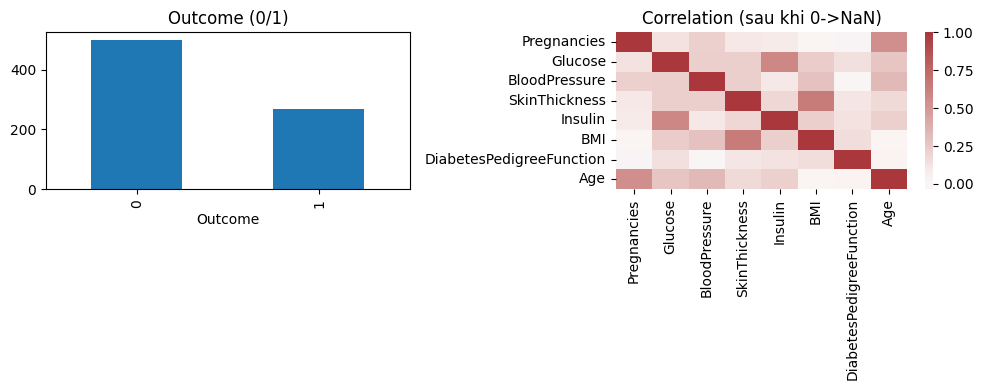

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
y.value_counts().plot(kind="bar", ax=ax[0], title="Outcome (0/1)")
ax[0].set_xlabel("Outcome")
sns.heatmap(diabetes.drop(columns=["Outcome"]).corr(), ax=ax[1], cmap="vlag", center=0)
ax[1].set_title("Correlation (sau khi 0->NaN)")
plt.tight_layout()
plt.show()

## Pipeline & siêu tham số (khớp Phụ lục A / `main.tex`)

- Lưới dưới đây là **ví dụ hợp lý**; có thể thu hẹp khi cần chạy nhanh.
- Mọi bước `imputer` / `scaler` nằm trong `Pipeline` → không fit trên test.

In [19]:
def make_base_pipeline(classifier) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", classifier),
        ]
    )


inner_cv = StratifiedKFold(n_splits=N_INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE_CV)

MODEL_GRIDS: list[tuple[str, object, dict]] = [
    (
        "Logistic Regression",
        LogisticRegression(max_iter=10_000, random_state=SEED_MODEL, class_weight=None),
        {
            "clf__C": [0.01, 0.1, 1.0, 10.0],
            "clf__solver": ["lbfgs"],
        },
    ),
    (
        "SVM (RBF)",
        SVC(kernel="rbf", probability=True, random_state=SEED_MODEL, class_weight=None),
        {"clf__C": [0.1, 1.0, 10.0], "clf__gamma": ["scale", 0.01, 0.1]},
    ),
    (
        "Random Forest",
        RandomForestClassifier(random_state=SEED_MODEL, class_weight=None, n_jobs=-1),
        {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [None, 8, 16],
            "clf__min_samples_leaf": [1, 2],
        },
    ),
    (
        "KNN",
        KNeighborsClassifier(),
        {
            "clf__n_neighbors": [3, 5, 7, 9],
            "clf__weights": ["uniform", "distance"],
            "clf__p": [2],
        },
    ),
    (
        "Majority (baseline)",
        DummyClassifier(strategy="most_frequent"),
        {},  # không tune
    ),
]


def evaluate_split(X_tr, X_te, y_tr, y_te, name, base_estimator, param_grid, inner_cv):
    pipe = make_base_pipeline(base_estimator)
    if not param_grid:
        pipe.fit(X_tr, y_tr)
        best = pipe
    else:
        search = GridSearchCV(
            pipe,
            param_grid,
            cv=inner_cv,
            scoring="f1",
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_tr, y_tr)
        best = search.best_estimator_
    y_pred = best.predict(X_te)
    proba = None
    if hasattr(best.named_steps["clf"], "predict_proba"):
        proba = best.predict_proba(X_te)[:, 1]
    elif hasattr(best.named_steps["clf"], "decision_function"):
        proba = best.decision_function(X_te)
    out = {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
    }
    try:
        out["roc_auc"] = roc_auc_score(y_te, proba) if proba is not None else np.nan
    except ValueError:
        out["roc_auc"] = np.nan
    return out, best, y_pred, proba


rows = []
fitted_by_seed: dict[int, dict[str, object]] = {}

for split_seed in SPLIT_SEEDS:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=split_seed
    )
    fitted_by_seed[split_seed] = {}
    for name, est, grid in MODEL_GRIDS:
        m, fitted, _, _ = evaluate_split(
            X_train, X_test, y_train, y_test, name, clone(est), grid, inner_cv
        )
        m["split_seed"] = split_seed
        rows.append(m)
        fitted_by_seed[split_seed][name] = fitted

results = pd.DataFrame(rows)
summary = results.groupby("model")[["accuracy", "precision", "recall", "f1", "roc_auc"]].agg(["mean", "std"])
summary

accuracy           precision              recall  \
                         mean       std      mean       std      mean   
model                                                                   
KNN                  0.728571  0.032919  0.625598  0.057000  0.574074   
Logistic Regression  0.748052  0.018019  0.693537  0.055888  0.518519   
Majority (baseline)  0.649351  0.000000  0.000000  0.000000  0.000000   
Random Forest        0.742857  0.023681  0.655968  0.059057  0.585185   
SVM (RBF)            0.736364  0.035149  0.675214  0.078894  0.503704   

                                     f1             roc_auc            
                          std      mean       std      mean       std  
model                                                                  
KNN                  0.086860  0.595456  0.058359  0.778426  0.023425  
Logistic Regression  0.045361  0.590412  0.016544  0.824370  0.030741  
Majority (baseline)  0.000000  0.000000  0.000000  0.500000  0.000000  
Random Forest        0.070028  0.614100  0.025179  0.823185  0.024523  
SVM (RBF)            0.068544  0.571911  0.045691  0.805296  0.059196

In [20]:
# Bảng mean ± std theo các split_seed (báo cáo trong main.tex)
def fmt_mean_std(g):
    m = g["mean"]
    s = g["std"]
    return (m.map(lambda x: f"{x:.4f}") + " ± " + s.map(lambda x: f"{x:.4f}")).rename("value")


display_tbl = pd.DataFrame(
    {
        c: fmt_mean_std(summary[c])
        for c in summary.columns.levels[0]
    }
)
display_tbl

,accuracy,precision,recall,f1,roc_auc
model,,,,,
KNN,0.7286 ± 0.0329,0.6256 ± 0.0570,0.5741 ± 0.0869,0.5955 ± 0.0584,0.7784 ± 0.0234
Logistic Regression,0.7481 ± 0.0180,0.6935 ± 0.0559,0.5185 ± 0.0454,0.5904 ± 0.0165,0.8244 ± 0.0307
Majority (baseline),0.6494 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.5000 ± 0.0000
Random Forest,0.7429 ± 0.0237,0.6560 ± 0.0591,0.5852 ± 0.0700,0.6141 ± 0.0252,0.8232 ± 0.0245
SVM (RBF),0.7364 ± 0.0351,0.6752 ± 0.0789,0.5037 ± 0.0685,0.5719 ± 0.0457,0.8053 ± 0.0592


### Kiểm định cặp (tùy chọn): Wilcoxon trên F1 giữa hai mô hình theo từng `split_seed`

Chỉ mang tính minh họa: so sánh hai mô hình có F1 gần nhau trên cùng các split.

In [21]:
def wilcoxon_f1(model_a: str, model_b: str) -> tuple[float, float]:
    a = results.loc[results["model"] == model_a, "f1"].values
    b = results.loc[results["model"] == model_b, "f1"].values
    if len(a) != len(b):
        raise ValueError("length mismatch")
    stat, p = stats.wilcoxon(a, b, zero_method="wilcox", alternative="two-sided")
    return stat, p


# Đổi tên mô hình nếu cần (phải khớp chuỗi trong MODEL_GRIDS)
best_two = summary["f1"]["mean"].sort_values(ascending=False).index[:2].tolist()
print("Hai mô hình F1 cao nhất (mean):", best_two)
wilcoxon_summary = ""
if len(best_two) == 2:
    stat, p = wilcoxon_f1(best_two[0], best_two[1])
    wilcoxon_summary = f"Models: {best_two[0]} vs {best_two[1]}\nWilcoxon statistic={stat:.6f}, p-value={p:.6f}\n"
    print(wilcoxon_summary.strip())

Hai mô hình F1 cao nhất (mean): ['Random Forest', 'KNN']
Models: Random Forest vs KNN
Wilcoxon statistic=4.000000, p-value=0.437500


In [22]:
# Khoảng tin cậy 95% (t-interval) cho mean F1 của từng mô hình qua len(SPLIT_SEEDS) split


def t_ci_95(values: np.ndarray) -> tuple[float, float]:
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n < 2:
        return float(np.mean(values)), float(np.mean(values))
    m = np.mean(values)
    sem = stats.sem(values)
    h = sem * stats.t.ppf((1 + 0.95) / 2.0, n - 1)
    return m - h, m + h


ci_rows = []
for name in results["model"].unique():
    vals = results.loc[results["model"] == name, "f1"].values
    lo, hi = t_ci_95(vals)
    ci_rows.append({"model": name, "f1_mean": np.mean(vals), "f1_ci95_low": lo, "f1_ci95_high": hi})

ci_f1_df = pd.DataFrame(ci_rows).sort_values("f1_mean", ascending=False)
ci_f1_df

,model,f1_mean,f1_ci95_low,f1_ci95_high
2,Random Forest,0.614100,0.582836,0.645365
3,KNN,0.595456,0.522994,0.667919
0,Logistic Regression,0.590412,0.569870,0.610954
1,SVM (RBF),0.571911,0.515178,0.628644
4,Majority (baseline),0.000000,0.000000,0.000000


## Diễn giải đặc trưng (RQ2) — trên một split cố định (`split_seed` = phần tử đầu của `SPLIT_SEEDS`)

Hệ số logistic trên dữ liệu **đã impute + scale**; RF: `feature_importances_`. **Không** nhân quả.

In [23]:
REF_SEED = SPLIT_SEEDS[0]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=REF_SEED
)

lr_pipe = make_base_pipeline(
    LogisticRegression(max_iter=10_000, random_state=SEED_MODEL, class_weight=None)
)
lr_search = GridSearchCV(
    lr_pipe,
    {"clf__C": [0.01, 0.1, 1.0, 10.0], "clf__solver": ["lbfgs"]},
    cv=inner_cv,
    scoring="f1",
    n_jobs=-1,
)
lr_search.fit(X_train, y_train)
lr_best = lr_search.best_estimator_
coefs = pd.Series(
    lr_best.named_steps["clf"].coef_.ravel(),
    index=X.columns,
    name="LR coefficient (scaled space)",
).sort_values(key=abs, ascending=False)
print(coefs)

rf_pipe = make_base_pipeline(
    RandomForestClassifier(random_state=SEED_MODEL, class_weight=None, n_jobs=-1)
)
rf_search = GridSearchCV(
    rf_pipe,
    {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [None, 8, 16],
        "clf__min_samples_leaf": [1, 2],
    },
    cv=inner_cv,
    scoring="f1",
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
imp = pd.Series(
    rf_best.named_steps["clf"].feature_importances_,
    index=X.columns,
    name="RF importance",
).sort_values(ascending=False)
print(imp)

Glucose                     0.884034
BMI                         0.468293
Pregnancies                 0.349834
DiabetesPedigreeFunction    0.257206
Age                         0.215009
SkinThickness               0.085906
Insulin                     0.060722
BloodPressure              -0.017959
Name: LR coefficient (scaled space), dtype: float64
Glucose                     0.244014
BMI                         0.166232
Age                         0.136054
DiabetesPedigreeFunction    0.129110
Insulin                     0.087578
BloodPressure               0.083693
Pregnancies                 0.081817
SkinThickness               0.071502
Name: RF importance, dtype: float64


In [24]:
# SHAP (tùy chọn): uv sync --extra shap
try:
    import shap

    X_tr_imp = rf_best.named_steps["imputer"].transform(X_train)
    X_tr_imp = rf_best.named_steps["scaler"].transform(X_tr_imp)
    explainer = shap.TreeExplainer(rf_best.named_steps["clf"])
    sv = explainer.shap_values(X_tr_imp)
    if isinstance(sv, list):
        sv = sv[1]
    shap.summary_plot(sv, pd.DataFrame(X_tr_imp, columns=X.columns), show=True)
except ImportError:
    print("Bỏ qua SHAP (chưa cài). Cài: uv sync --extra shap")

Bỏ qua SHAP (chưa cài). Cài: uv sync --extra shap


## ROC & ma trận nhầm lẫn (`split_seed=REF_SEED`, mô hình F1 cao nhất theo mean)

Lưu hình vào `image/roc_confusion_test_seed*.png` để chèn LaTeX (`\includegraphics`).

Best by mean F1: Random Forest


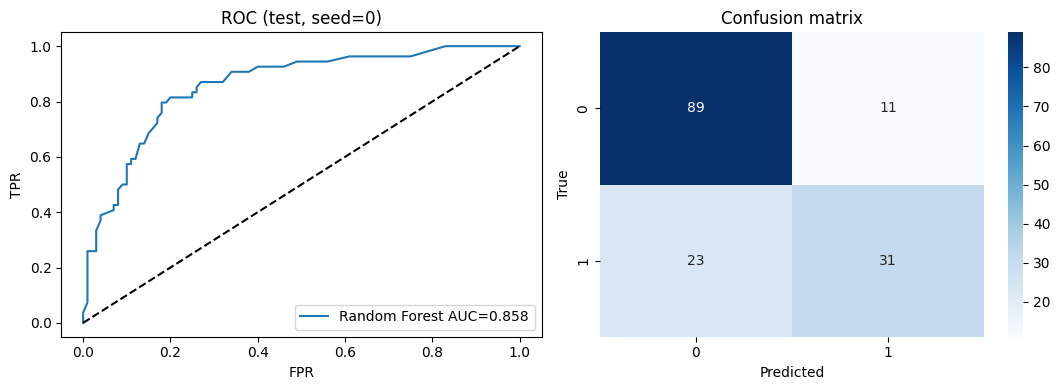

              precision    recall  f1-score   support

           0     0.7946    0.8900    0.8396       100
           1     0.7381    0.5741    0.6458        54

    accuracy                         0.7792       154
   macro avg     0.7664    0.7320    0.7427       154
weighted avg     0.7748    0.7792    0.7717       154



In [25]:
REF_SEED = SPLIT_SEEDS[0]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=REF_SEED
)

mean_f1 = results.groupby("model")["f1"].mean().sort_values(ascending=False)
best_name = mean_f1.index[0]
print("Best by mean F1:", best_name)

best_model = fitted_by_seed[REF_SEED][best_name]
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[0].plot(fpr, tpr, label=f"{best_name} AUC={roc_auc_score(y_test, y_proba):.3f}")
ax[0].plot([0, 1], [0, 1], "k--")
ax[0].set_xlabel("FPR")
ax[0].set_ylabel("TPR")
ax[0].set_title(f"ROC (test, seed={REF_SEED})")
ax[0].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[1])
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")
ax[1].set_title("Confusion matrix")
plt.tight_layout()
_img_dir = REPO_ROOT / "image"
_img_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(_img_dir / f"roc_confusion_test_seed{REF_SEED}.png", dpi=200, bbox_inches="tight")
plt.show()
print(classification_report(y_test, y_pred, digits=4))

## Ablation (khớp gợi ý `main.tex`): có / không `StandardScaler` — logistic cố định (`C=1`), một split

So sánh nhanh F1 trên cùng tập test; không thay thế lưới siêu tham số đầy đủ ở trên.

In [26]:
REF_SEED = SPLIT_SEEDS[0]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=REF_SEED
)
lr_a = LogisticRegression(max_iter=10_000, random_state=SEED_MODEL, C=1.0)
pipe_scaled = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", lr_a),
    ]
)
lr_b = LogisticRegression(max_iter=10_000, random_state=SEED_MODEL, C=1.0)
pipe_no_scale = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", lr_b),
    ]
)
pipe_scaled.fit(X_train, y_train)
pipe_no_scale.fit(X_train, y_train)
_f1_sc = f1_score(y_test, pipe_scaled.predict(X_test))
_f1_ns = f1_score(y_test, pipe_no_scale.predict(X_test))
ablation_lr_f1 = pd.DataFrame(
    [
        {"variant": "LR + impute + StandardScaler", "f1_test": _f1_sc},
        {"variant": "LR + impute (no scaler)", "f1_test": _f1_ns},
    ]
)
print("F1 (LR + impute + scale):", _f1_sc)
print("F1 (LR + impute, không scale):", _f1_ns)

F1 (LR + impute + scale): 0.6236559139784946
F1 (LR + impute, không scale): 0.6236559139784946


## Lưu mô hình tốt nhất (theo mean F1) — `joblib`

In [27]:
out_path = REPO_ROOT / "resources" / "diabetes_prediction_model.pkl"
joblib.dump(best_model, out_path)
print("Đã lưu:", out_path.resolve())

Đã lưu: /home/ubuntu/Projects/ppnckh/resources/diabetes_prediction_model.pkl


## Xuất kết quả ra `resources/outputs/` (CSV, JSON, hình)

Hàm `save_run_outputs` trong `resources/export_run.py` ghi:

- `resources/outputs/latest/` — bản mới nhất (ghi đè mỗi lần **Run All**),
- `resources/outputs/runs/<timestamp>/` — bản lưu theo thời điểm.

Có thể trích dữ liệu từ đây vào bảng LaTeX (`main.tex`).

In [28]:
import importlib.util

_spec = importlib.util.spec_from_file_location(
    "export_run", REPO_ROOT / "resources" / "export_run.py"
)
_export = importlib.util.module_from_spec(_spec)
assert _spec.loader is not None
_spec.loader.exec_module(_export)

saved_to = _export.save_run_outputs(
    REPO_ROOT,
    results=results,
    summary=summary,
    display_tbl=display_tbl,
    ci_f1=ci_f1_df,
    wilcoxon_summary=wilcoxon_summary,
    ablation_lr_f1=ablation_lr_f1,
    lr_coefs=coefs,
    rf_importance=imp,
    model_pkl_relative="resources/diabetes_prediction_model.pkl",
    extra_manifest={
        "RANDOM_STATE_CV": RANDOM_STATE_CV,
        "SEED_MODEL": SEED_MODEL,
        "SPLIT_SEEDS": list(SPLIT_SEEDS),
        "TEST_SIZE": TEST_SIZE,
        "N_INNER_SPLITS": N_INNER_SPLITS,
        "best_model_by_mean_f1": str(
            results.groupby("model")["f1"].mean().sort_values(ascending=False).index[0]
        ),
    },
)
print("Đã xuất artifact tới:", saved_to.resolve())

Đã xuất artifact tới: /home/ubuntu/Projects/ppnckh/resources/outputs/latest
